In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 500)

sns.set_style("whitegrid")

In [2]:
df = pd.read_excel("Online+Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df = df.dropna(subset="CustomerID")

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
df.shape

(406829, 8)

In [10]:
df.duplicated().sum()

np.int64(5225)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(401604, 8)

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401604.000000,401604,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,250.283037,NaN,69.764035,1714.006089


In [14]:
df[df.Quantity < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [15]:
df["SalesQuantity"] = np.where(df["Quantity"] >= 0, df["Quantity"], 0)

In [16]:
df["ReturnQuantity"] = np.where(df["Quantity"] < 0, df["Quantity"], 0)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       401604 non-null  object        
 1   StockCode       401604 non-null  object        
 2   Description     401604 non-null  object        
 3   Quantity        401604 non-null  int64         
 4   InvoiceDate     401604 non-null  datetime64[us]
 5   UnitPrice       401604 non-null  float64       
 6   CustomerID      401604 non-null  float64       
 7   Country         401604 non-null  str           
 8   SalesQuantity   401604 non-null  int64         
 9   ReturnQuantity  401604 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), object(3), str(1)
memory usage: 38.8+ MB


In [18]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesQuantity,ReturnQuantity
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,0,-1
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,0,-1
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,0,-12
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,0,-24
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,0,-24
...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,0,-11
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,0,-1
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,0,-5
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,0,-1


In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesQuantity,ReturnQuantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,8,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0


In [20]:
df["ReturnQuantity"] = df["ReturnQuantity"].abs()

In [21]:
df["Revenue"] = df["SalesQuantity"] * df["UnitPrice"]

In [22]:
df["ReturnRevenue"] = df["ReturnQuantity"] * df["UnitPrice"]

In [23]:
df["NetRevenue"] = df["Revenue"] - df["ReturnRevenue"]

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesQuantity,ReturnQuantity,Revenue,ReturnRevenue,NetRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,0,15.30,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,8,0,22.00,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34


In [25]:
df[df["Revenue"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesQuantity,ReturnQuantity,Revenue,ReturnRevenue,NetRevenue


In [26]:
df[df["NetRevenue"]<0].value_counts()

InvoiceNo  StockCode  Description                       Quantity  InvoiceDate          UnitPrice  CustomerID  Country         SalesQuantity  ReturnQuantity  Revenue  ReturnRevenue  NetRevenue
C536379    D          Discount                          -1        2010-12-01 09:41:00  27.50      14527.0     United Kingdom  0              1               0.0      27.50          -27.50        1
C536383    35004C     SET OF 3 COLOURED  FLYING DUCKS   -1        2010-12-01 09:49:00  4.65       15311.0     United Kingdom  0              1               0.0      4.65           -4.65         1
C536391    22556      PLASTERS IN TIN CIRCUS PARADE     -12       2010-12-01 10:24:00  1.65       17548.0     United Kingdom  0              12              0.0      19.80          -19.80        1
           21984      PACK OF 12 PINK PAISLEY TISSUES   -24       2010-12-01 10:24:00  0.29       17548.0     United Kingdom  0              24              0.0      6.96           -6.96         1
           21983    

In [27]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
SalesQuantity     0
ReturnQuantity    0
Revenue           0
ReturnRevenue     0
NetRevenue        0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesQuantity,ReturnQuantity,Revenue,ReturnRevenue,NetRevenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,6,0,15.30,0.0,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,8,0,22.00,0.0,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,6,0,20.34,0.0,20.34,2010,12


In [31]:
product_df = df.groupby(["StockCode", "Description"]).agg(TotalRevenue = ("Revenue", "sum"),
                                                          TotalCustomers = ("CustomerID", "nunique"),
                                                          TotalSalesQuantity = ("SalesQuantity", "sum"),
                                                          TotalReturnQuantity = ("ReturnQuantity", "sum"),
                                                          TotalOrders = ("InvoiceNo", "nunique"),
                                                          TotalMonths = ("Month", "nunique"),
                                                          TotalReturnValue = ("ReturnRevenue","sum"),
                                                          TotalNetRevenue = ("NetRevenue", "sum"),
                                                          AveragePrice = ("UnitPrice", "mean")).reset_index()

In [32]:
product_df["ReturnRate"] = product_df["TotalReturnQuantity"] / (product_df["TotalSalesQuantity"] + product_df["TotalReturnQuantity"])

In [33]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196


In [34]:
product_df["QuantityPerOrder"] = (product_df["TotalSalesQuantity"] + product_df["TotalReturnQuantity"]) / product_df["TotalOrders"]

In [35]:
product_df["RevenuePerOrder"] = (product_df["TotalNetRevenue"] / product_df["TotalOrders"])

In [36]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,16.795918,14.276531
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,13.857143,5.448095
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,6.620690,1.390345
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.081967,15.236885
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.373984,9.225935


In [37]:
product_df["QuantityPerOrder"] = product_df["QuantityPerOrder"].round()

In [38]:
product_df["RevenuePerOrder"] = product_df["RevenuePerOrder"].round(decimals=2)

In [39]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23


In [40]:
product_df[product_df["TotalRevenue"]<0].value_counts()

Series([], Name: count, dtype: int64)

In [41]:
product_df[product_df["TotalNetRevenue"]<0].value_counts().sum()

np.int64(27)

In [42]:
sales_days = (
    df.groupby("StockCode")["InvoiceDate"]
      .agg(["min", "max"])
      .reset_index()
)

sales_days["SalesDays"] = (
    sales_days["max"] - sales_days["min"]
).dt.days + 1

In [43]:
product_df = product_df.merge(
    sales_days[["StockCode", "SalesDays"]],
    on="StockCode",
    how="left"
)

In [44]:
product_df["SalesVelocity"] = ((product_df["TotalSalesQuantity"] + product_df["TotalReturnQuantity"]) / product_df["SalesDays"]
)

In [45]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28,139,5.920863
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45,268,1.085821
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39,367,0.523161
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24,373,3.284182
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23,280,8.510714


In [46]:
product_df.isnull().sum()

StockCode              0
Description            0
TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalMonths            0
TotalReturnValue       0
TotalNetRevenue        0
AveragePrice           0
ReturnRate             0
QuantityPerOrder       0
RevenuePerOrder        0
SalesDays              0
SalesVelocity          0
dtype: int64

In [47]:
product_df.describe()

,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity
count,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000
mean,2269.460902,68.761491,1319.174157,69.722932,101.298008,7.533453,155.436535,2114.024368,3.980882,0.028005,32.686925,23.317722,263.362615,46.557505
std,6302.662339,89.522293,3344.995558,1769.082848,157.784208,3.929800,3481.996684,5391.810801,19.619034,0.096132,1294.471858,321.760226,125.881772,2588.558310
min,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-58745.460000,0.000750,0.000000,1.000000,-495.840000,1.000000,0.002710
25%,108.807500,9.000000,52.000000,0.000000,10.000000,4.000000,0.000000,105.217500,1.009904,0.000000,4.000000,7.827500,172.000000,0.395309
50%,565.855000,35.000000,334.500000,0.000000,43.000000,8.000000,0.000000,546.650000,1.950000,0.000000,7.000000,12.750000,334.000000,1.690806
75%,1964.512500,94.000000,1307.750000,12.000000,126.000000,12.000000,24.135000,1920.420000,3.881941,0.015978,14.000000,19.922500,370.000000,5.237859
max,168469.600000,887.000000,80995.000000,80995.000000,2013.000000,12.000000,168469.600000,132567.700000,744.147500,1.000000,80995.000000,19809.750000,374.000000,161990.000000


In [48]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28,139,5.920863
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45,268,1.085821
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39,367,0.523161
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24,373,3.284182
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23,280,8.510714


In [49]:
product_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TotalRevenue,3916.0,2269.460902,6302.662339,0.00000,108.807500,565.855000,1964.512500,168469.6000
TotalCustomers,3916.0,68.761491,89.522293,1.00000,9.000000,35.000000,94.000000,887.0000
TotalSalesQuantity,3916.0,1319.174157,3344.995558,0.00000,52.000000,334.500000,1307.750000,80995.0000
TotalReturnQuantity,3916.0,69.722932,1769.082848,0.00000,0.000000,0.000000,12.000000,80995.0000
TotalOrders,3916.0,101.298008,157.784208,1.00000,10.000000,43.000000,126.000000,2013.0000
TotalMonths,3916.0,7.533453,3.929800,1.00000,4.000000,8.000000,12.000000,12.0000
TotalReturnValue,3916.0,155.436535,3481.996684,0.00000,0.000000,0.000000,24.135000,168469.6000
TotalNetRevenue,3916.0,2114.024368,5391.810801,-58745.46000,105.217500,546.650000,1920.420000,132567.7000
AveragePrice,3916.0,3.980882,19.619034,0.00075,1.009904,1.950000,3.881941,744.1475
ReturnRate,3916.0,0.028005,0.096132,0.00000,0.000000,0.000000,0.015978,1.0000


In [50]:
product_df.columns.to_list()

['StockCode',
 'Description',
 'TotalRevenue',
 'TotalCustomers',
 'TotalSalesQuantity',
 'TotalReturnQuantity',
 'TotalOrders',
 'TotalMonths',
 'TotalReturnValue',
 'TotalNetRevenue',
 'AveragePrice',
 'ReturnRate',
 'QuantityPerOrder',
 'RevenuePerOrder',
 'SalesDays',
 'SalesVelocity']

In [51]:
features = [
 'TotalRevenue',
 'TotalCustomers',
 'TotalSalesQuantity',
 'TotalReturnQuantity',
 'TotalOrders',
 #'TotalMonths',
 'TotalReturnValue',
 'AveragePrice',
 'ReturnRate',
 'QuantityPerOrder',
 #'SalesDays',
 'SalesVelocity'
 ]

In [52]:
X = product_df[features].copy()

In [53]:
X.isnull().sum()

TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalReturnValue       0
AveragePrice           0
ReturnRate             0
QuantityPerOrder       0
SalesVelocity          0
dtype: int64

In [54]:
X = X.replace([np.inf, -np.inf], np.nan)

In [55]:
X.isnull().sum()

TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalReturnValue       0
AveragePrice           0
ReturnRate             0
QuantityPerOrder       0
SalesVelocity          0
dtype: int64

In [56]:
np.isinf(X).sum()

TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalReturnValue       0
AveragePrice           0
ReturnRate             0
QuantityPerOrder       0
SalesVelocity          0
dtype: int64

In [57]:
for col in X.columns:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = X[col].clip(lower, upper)

In [58]:
log_features = [
 'TotalRevenue',
 'TotalCustomers',
 'TotalSalesQuantity',
 'TotalReturnQuantity',
 'TotalOrders',
 'TotalReturnValue',
 'AveragePrice',
 'QuantityPerOrder',
 'SalesVelocity'
 ]

In [59]:
X_log = np.log1p(X[log_features])

In [60]:
X_log.isnull().sum()

TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalReturnValue       0
AveragePrice           0
QuantityPerOrder       0
SalesVelocity          0
dtype: int64

In [61]:
-np.isinf(X_log).sum()

TotalRevenue           0
TotalCustomers         0
TotalSalesQuantity     0
TotalReturnQuantity    0
TotalOrders            0
TotalReturnValue       0
AveragePrice           0
QuantityPerOrder       0
SalesVelocity          0
dtype: int64

array([[<Axes: title={'center': 'TotalRevenue'}>,
        <Axes: title={'center': 'TotalCustomers'}>,
        <Axes: title={'center': 'TotalSalesQuantity'}>],
       [<Axes: title={'center': 'TotalReturnQuantity'}>,
        <Axes: title={'center': 'TotalOrders'}>,
        <Axes: title={'center': 'TotalReturnValue'}>],
       [<Axes: title={'center': 'AveragePrice'}>,
        <Axes: title={'center': 'QuantityPerOrder'}>,
        <Axes: title={'center': 'SalesVelocity'}>]], dtype=object)

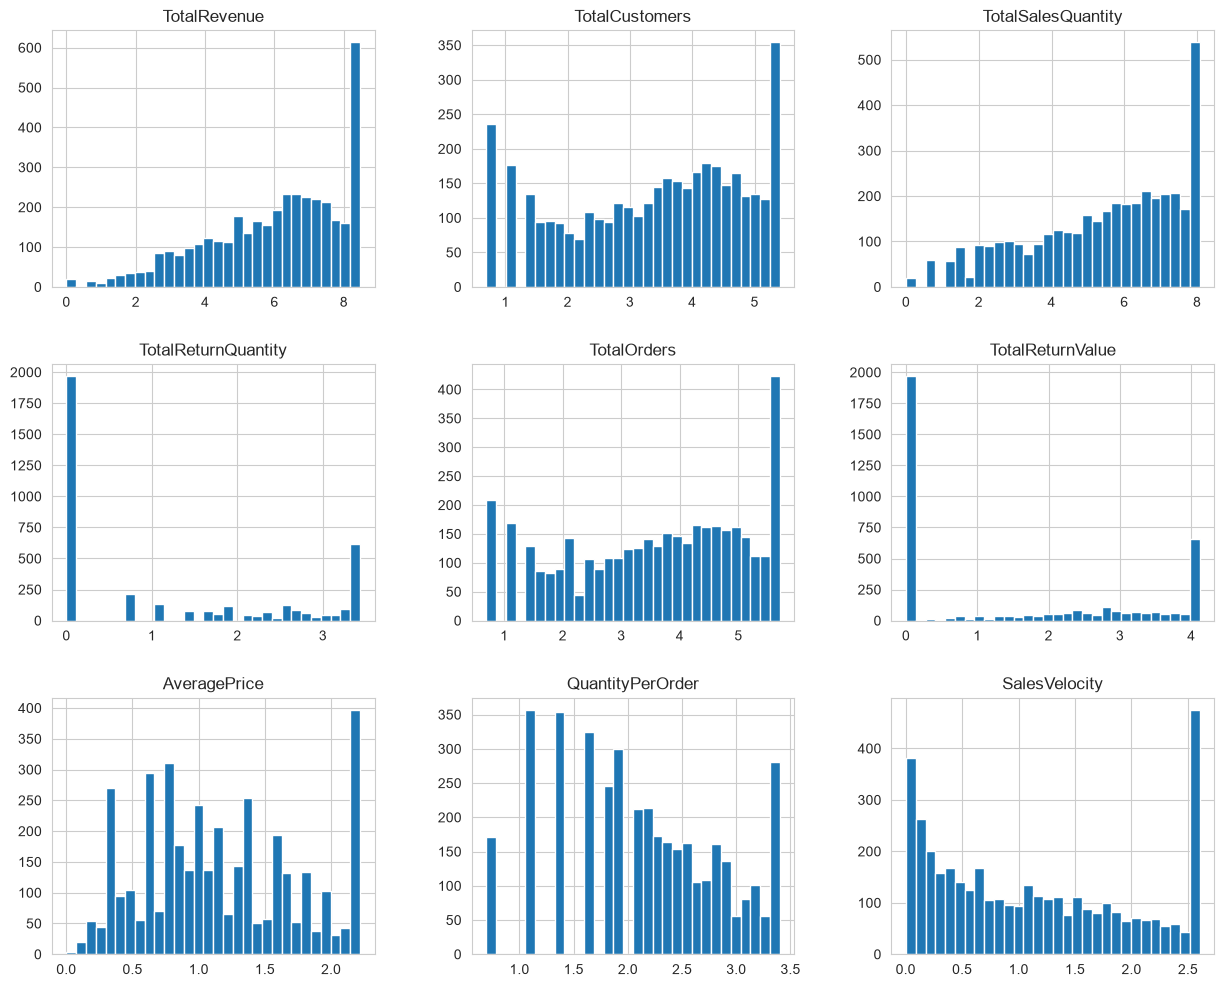

In [62]:
X_log.hist(
    figsize=(15, 12),
    bins=30
)

In [63]:
X_log.head()

,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalReturnValue,AveragePrice,QuantityPerOrder,SalesVelocity
0,6.551866,3.713572,6.714171,0.000000,3.912023,0.000000,0.615186,2.890372,1.934541
1,4.748491,2.995732,5.676754,0.000000,3.091042,0.000000,0.344940,2.708050,0.735162
2,3.721347,3.258097,5.262690,0.000000,3.401197,0.000000,0.190620,2.079442,0.420788
3,6.835668,3.912023,7.111512,0.000000,4.127134,0.000000,0.577594,3.044522,1.454930
4,7.038775,4.624973,7.772332,2.397895,4.820282,1.648659,0.424204,2.995732,2.252419


In [64]:
raw_features = [
    "ReturnRate",
    #"SalesDays",
    #"TotalMonths"
]

In [65]:
X = pd.concat([X_log, X[raw_features]], axis=1)

In [66]:
X.head()

,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalReturnValue,AveragePrice,QuantityPerOrder,SalesVelocity,ReturnRate
0,6.551866,3.713572,6.714171,0.000000,3.912023,0.000000,0.615186,2.890372,1.934541,0.000000
1,4.748491,2.995732,5.676754,0.000000,3.091042,0.000000,0.344940,2.708050,0.735162,0.000000
2,3.721347,3.258097,5.262690,0.000000,3.401197,0.000000,0.190620,2.079442,0.420788,0.000000
3,6.835668,3.912023,7.111512,0.000000,4.127134,0.000000,0.577594,3.044522,1.454930,0.000000
4,7.038775,4.624973,7.772332,2.397895,4.820282,1.648659,0.424204,2.995732,2.252419,0.004196


In [67]:

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    Birch,
    SpectralClustering
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import warnings
warnings.filterwarnings("ignore")

In [68]:
X.columns.tolist()

['TotalRevenue',
 'TotalCustomers',
 'TotalSalesQuantity',
 'TotalReturnQuantity',
 'TotalOrders',
 'TotalReturnValue',
 'AveragePrice',
 'QuantityPerOrder',
 'SalesVelocity',
 'ReturnRate']

In [69]:
#Standardisinth data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [70]:
#PCA decompose

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [71]:
X_pca

array([[ 0.44506178, -2.18672601],
       [-0.97143947, -1.89656438],
       [-1.39502949, -1.56251655],
       ...,
       [ 4.2462569 ,  1.585572  ],
       [-4.26926907, -0.42261365],
       [ 3.44361897,  2.69304553]], shape=(3916, 2))

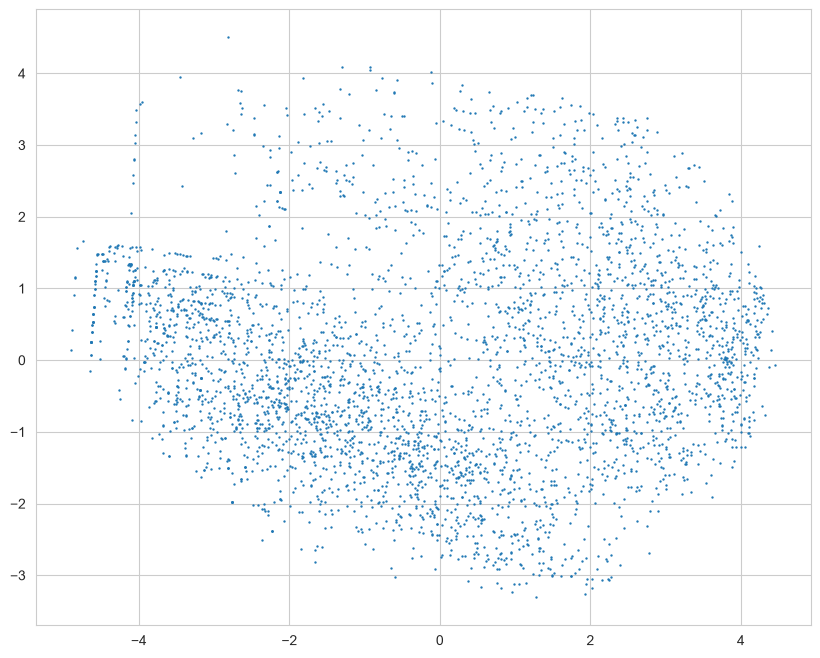

In [72]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1], marker="o", s=0.5)

In [73]:
#KMEANS CLUSTERING

inertia = []
silhouette_scores = []
db_scores = []

for k in range(2,11):

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)

    kmeans_preds = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_preds))
    db_scores.append(davies_bouldin_score(X_scaled, kmeans_preds))

In [74]:
inertia

[22451.567238058677,
 17339.358935220513,
 14540.377258233808,
 12943.330633508322,
 11699.929597275997,
 10539.51655001299,
 9578.94176338248,
 9044.266432458397,
 8516.474830183308]

In [75]:
silhouette_scores

[0.36321692639314695,
 0.30135049880668113,
 0.30210342890403497,
 0.26000534211731074,
 0.26229460476839417,
 0.26509865182894515,
 0.2697181880278608,
 0.25201225100576863,
 0.25504353461872614]

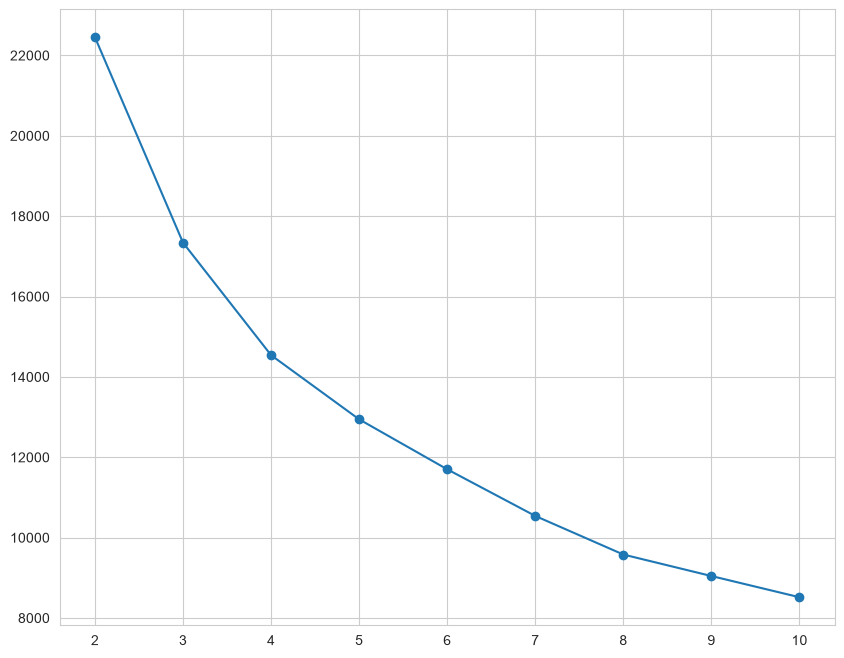

In [76]:
# Elbow Method
plt.figure(figsize=(10,8))
plt.plot(range(2,11), inertia, marker="o")

Text(0.5, 1.0, 'Kmeans SC Scores')

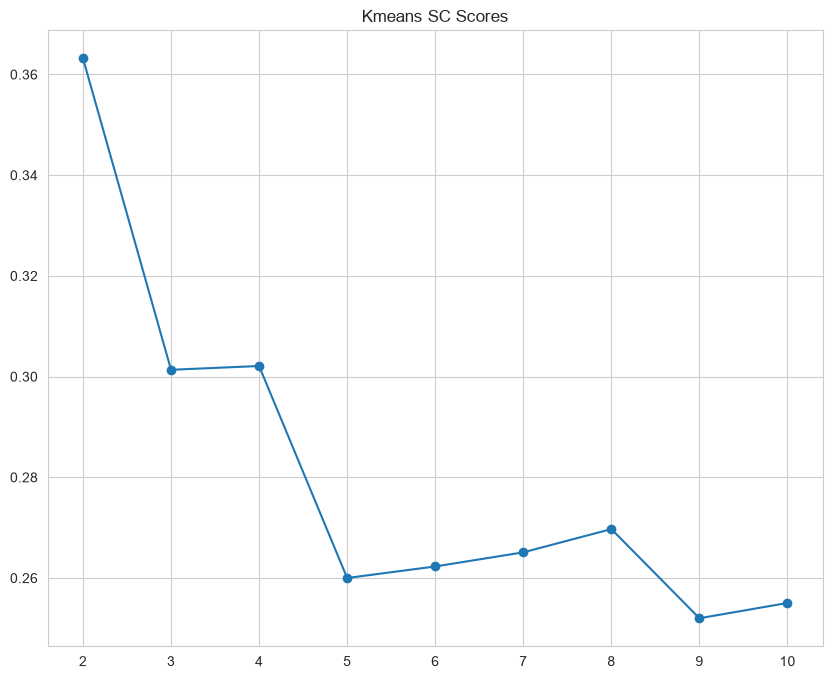

In [77]:
plt.figure(figsize=(10,8))
plt.plot(range(2,11), silhouette_scores, marker="o")
plt.title("Kmeans SC Scores")

Text(0.5, 1.0, 'Kmeans DB Scores')

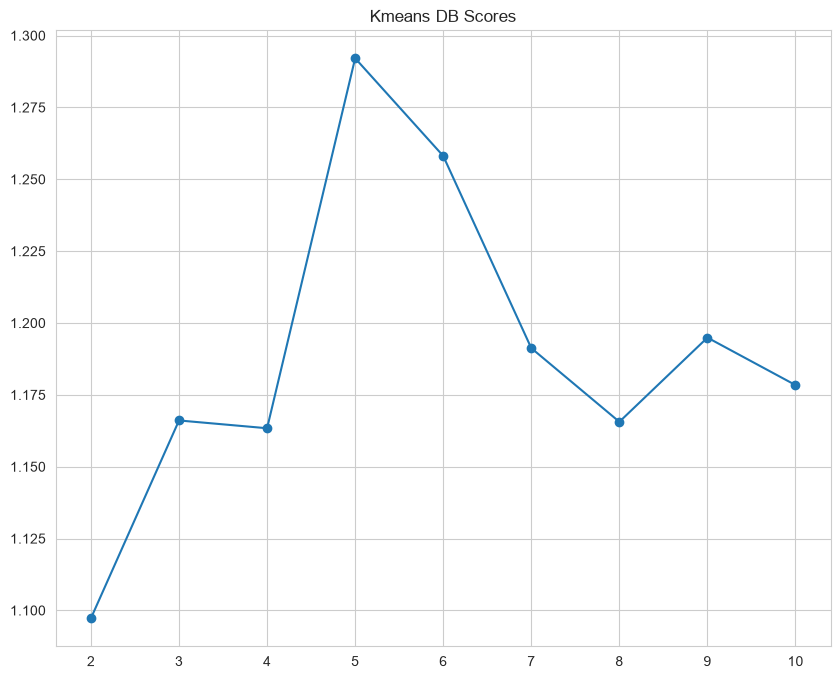

In [78]:
plt.figure(figsize=(10,8))
plt.plot(range(2,11), db_scores, marker="o")
plt.title("Kmeans DB Scores")

In [79]:
#Selecting the Final Kmeans Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

kmeans_Cluster = kmeans.fit_predict(
    X_scaled
)

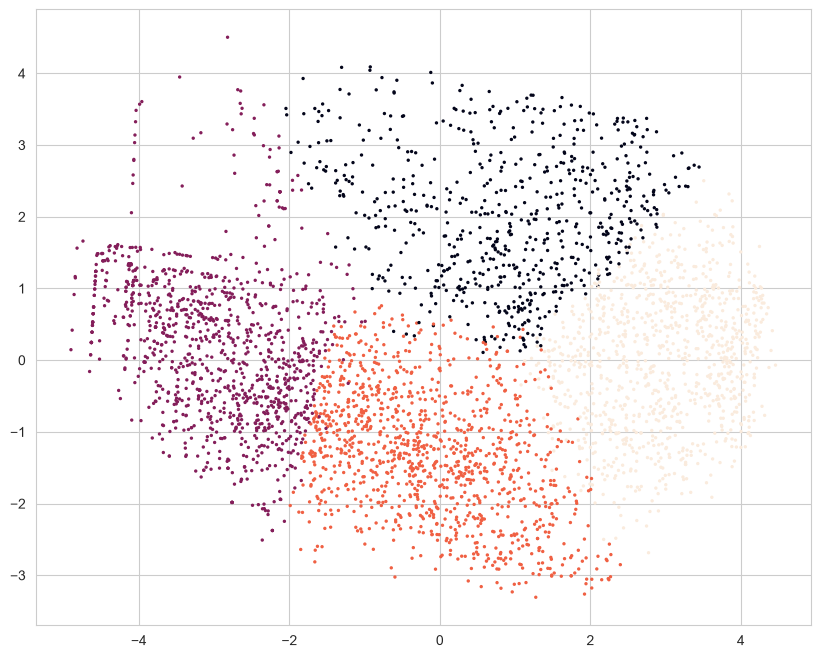

In [80]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1],  c = kmeans_Cluster, s = 2)

In [81]:
product_df["KMeansClusters"] = kmeans_Cluster

In [82]:
print(f"Silhouette_score :  {silhouette_score(X_scaled, kmeans_Cluster)}")
print(f"DB Score :  {davies_bouldin_score(X_scaled, kmeans_Cluster)}")
print(f"CH Score :  {calinski_harabasz_score(X_scaled, kmeans_Cluster)}")

Silhouette_score :  0.3020690370662996
DB Score :  1.1631665721440063
CH Score :  2207.9253950014067


In [83]:
#Hierarchical Clustering
hc_silhouette_scores = []
hc_db_scores = []

for k in range(2,11): 

    hierarchical = AgglomerativeClustering(n_clusters=k, linkage="ward")

    hc_preds = hierarchical.fit_predict(X_scaled)

    hc_silhouette_scores.append(silhouette_score(X_scaled, hc_preds))
    hc_db_scores.append(davies_bouldin_score(X_scaled, hc_preds))



Text(0.5, 1.0, 'Silhouette Scores Scores H Clusters')

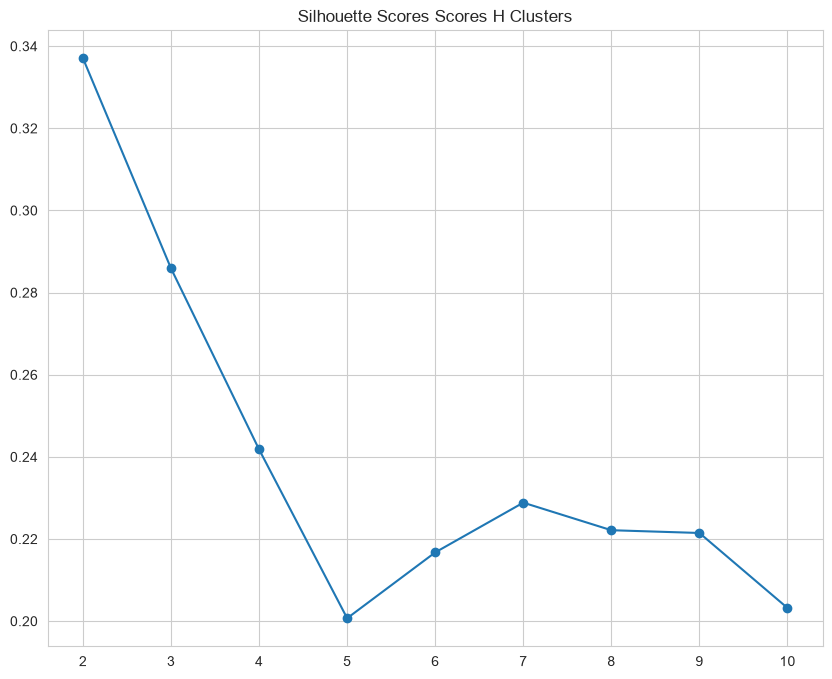

In [84]:
plt.figure(figsize=(10,8))
plt.plot(range(2,11), hc_silhouette_scores, marker="o")
plt.title("Silhouette Scores Scores H Clusters")

Text(0.5, 1.0, 'DB_Scores HClusters')

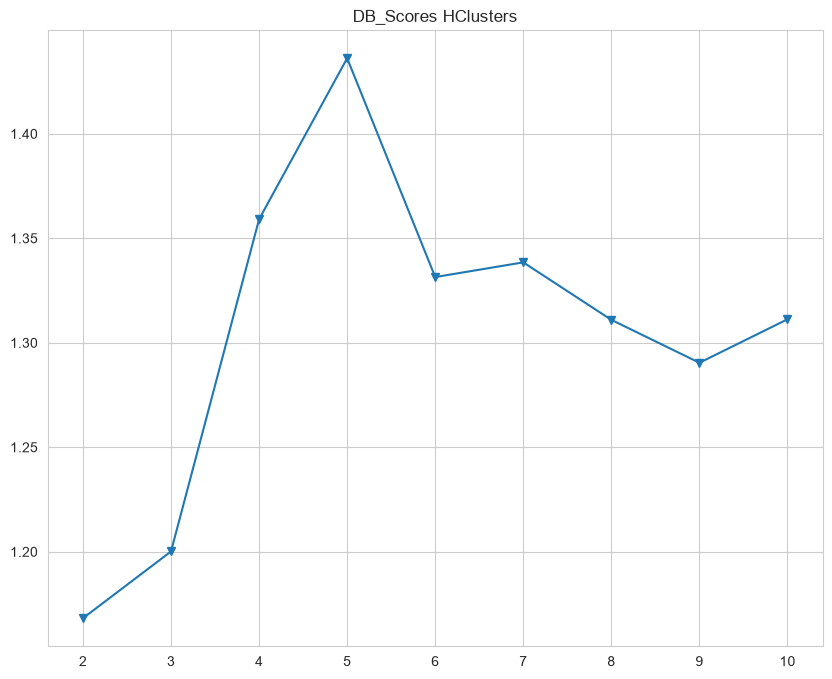

In [85]:
plt.figure(figsize=(10,8))
plt.plot(range(2,11), hc_db_scores, marker="v")
plt.title("DB_Scores HClusters")

In [86]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_Cluster = kmeans.fit_predict(
    X_scaled
)

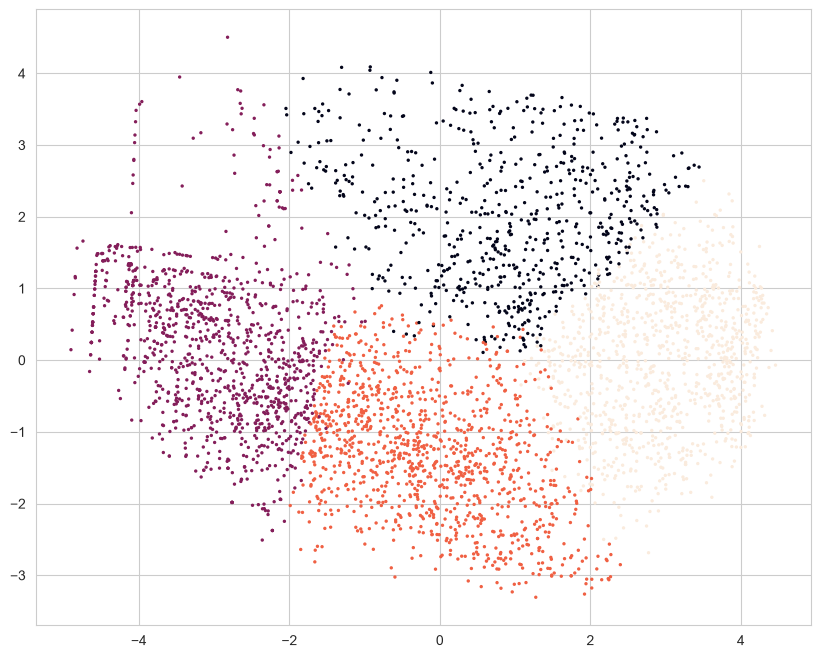

In [87]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1],  c = hierarchical_Cluster, s = 2)

In [88]:
product_df["HierarchicalClusters"] = hierarchical_Cluster

In [89]:
#Gaussian Mixture Model

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_Cluster = (
    gmm.fit_predict(X_scaled)
)

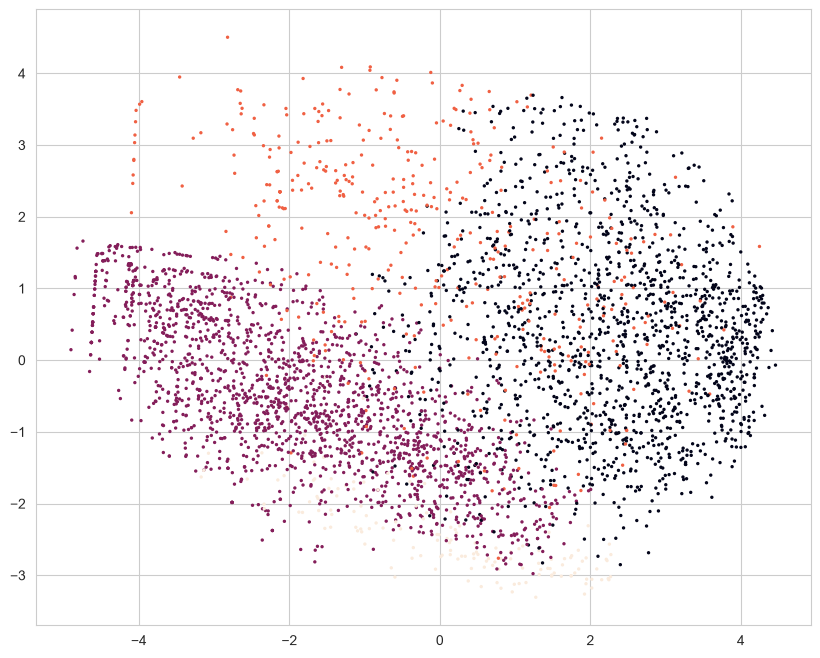

In [90]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1],  c = gmm_Cluster, s = 2)

In [91]:
gmm_prob = gmm.predict_proba(X_scaled)

In [92]:
gmm_prob

array([[3.12485080e-12, 9.92679667e-01, 4.82582898e-13, 7.32033332e-03],
       [2.03706411e-11, 9.99969135e-01, 5.41628344e-13, 3.08652942e-05],
       [3.07112183e-16, 1.00000000e+00, 7.91577363e-12, 7.20184286e-16],
       ...,
       [1.85808315e-09, 0.00000000e+00, 9.99999998e-01, 0.00000000e+00],
       [8.48103960e-81, 1.00000000e+00, 2.51898643e-15, 2.20259073e-87],
       [9.94466275e-01, 0.00000000e+00, 5.53372494e-03, 0.00000000e+00]],
      shape=(3916, 4))

In [93]:
aic_scores = []
bic_scores = []

k_values = range(2, 11)

for k in k_values:

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_scaled)

    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

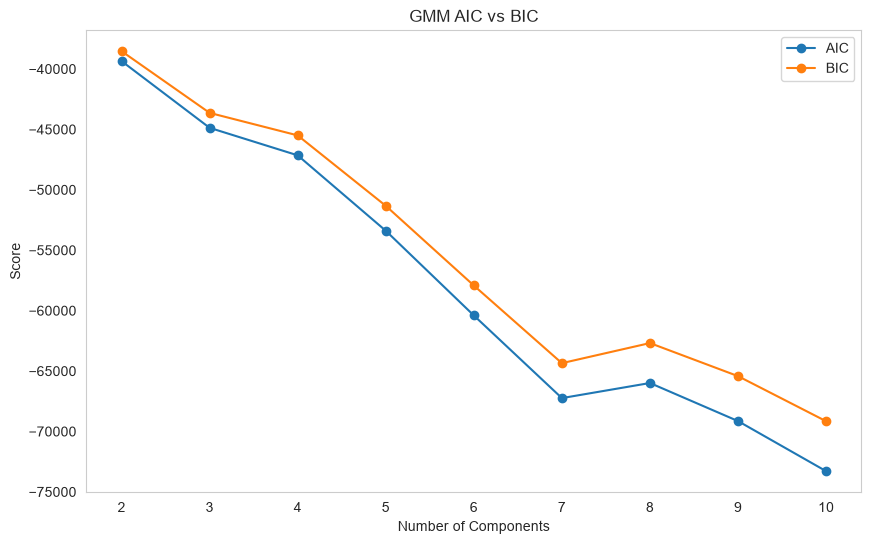

In [94]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, aic_scores, marker="o", label="AIC")
plt.plot(k_values, bic_scores, marker="o", label="BIC")

plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM AIC vs BIC")
plt.legend()
plt.grid()
plt.show()

In [95]:
product_df["GMMClusters"] = gmm_Cluster

In [96]:
product_df["GMMConfidence"] = gmm_prob.max(axis = 1)

In [97]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity,KMeansClusters,HierarchicalClusters,GMMClusters,GMMConfidence
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28,139,5.920863,2,2,1,0.992680
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45,268,1.085821,2,2,1,0.999969
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39,367,0.523161,2,2,1,1.000000
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24,373,3.284182,2,2,1,0.949408
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23,280,8.510714,3,3,0,0.999546


In [98]:
#DB Scan

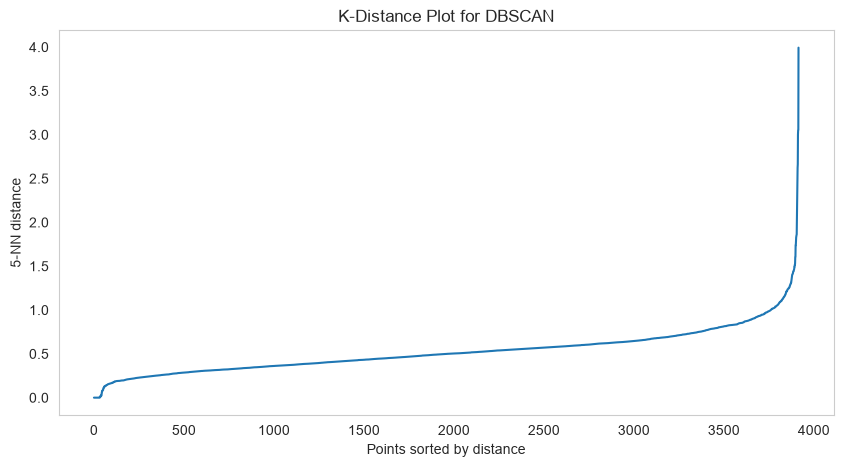

In [99]:
from sklearn.neighbors import NearestNeighbors

neighbours = NearestNeighbors(n_neighbors=5)
neighbours.fit(X_scaled)

distances, indices = neighbours.kneighbors(X_scaled)

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.title("K-Distance Plot for DBSCAN")
plt.grid()
plt.show()

In [100]:
dbscan = DBSCAN(eps = 1, min_samples=5)

dbscan_preds = dbscan.fit_predict(X_scaled)

In [101]:
dbscan_preds

array([ 0,  0,  0, ..., -1, -1,  0], shape=(3916,))

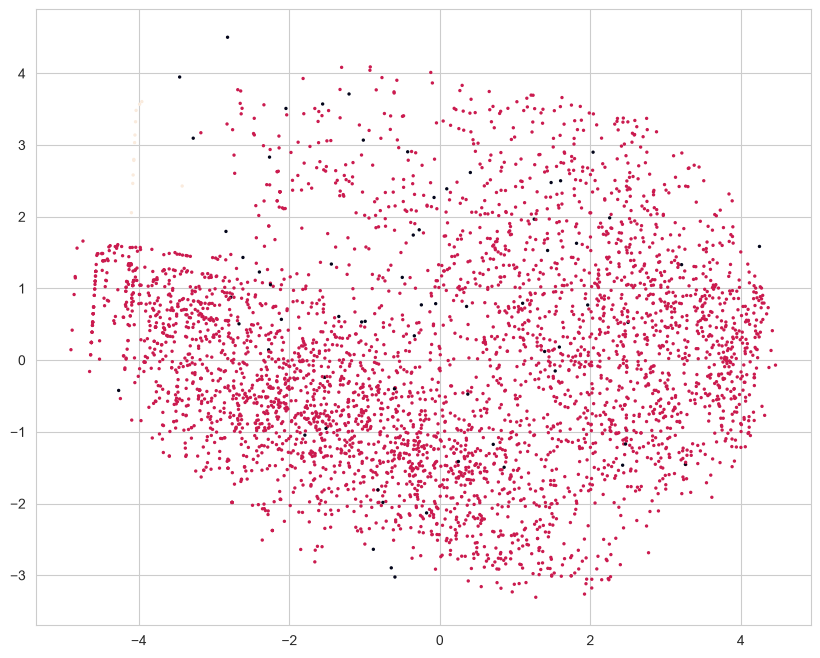

In [102]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1],  c = dbscan_preds, s = 2)

In [103]:
eps_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2]

for e in eps_values:

    dbscan = DBSCAN(eps = e, min_samples=5)

    dbscan_preds = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(dbscan_preds))
    noise = np.sum(dbscan_preds == -1)


    print(
        f"eps={e:.1f} | "
        f"clusters={n_clusters} | "
        f"noise={noise} "
        f"({noise/len(dbscan_preds):.1%})"
    )

eps=0.5 | clusters=53 | noise=1439 (36.7%)
eps=0.6 | clusters=25 | noise=724 (18.5%)
eps=0.7 | clusters=15 | noise=393 (10.0%)
eps=0.8 | clusters=8 | noise=225 (5.7%)
eps=0.9 | clusters=6 | noise=111 (2.8%)
eps=1.0 | clusters=3 | noise=66 (1.7%)
eps=1.1 | clusters=3 | noise=46 (1.2%)
eps=1.2 | clusters=3 | noise=34 (0.9%)
eps=1.3 | clusters=3 | noise=22 (0.6%)
eps=1.4 | clusters=3 | noise=16 (0.4%)
eps=1.5 | clusters=2 | noise=13 (0.3%)
eps=1.6 | clusters=2 | noise=12 (0.3%)
eps=1.7 | clusters=2 | noise=7 (0.2%)
eps=1.8 | clusters=2 | noise=7 (0.2%)
eps=1.9 | clusters=2 | noise=7 (0.2%)
eps=2.0 | clusters=2 | noise=7 (0.2%)


In [104]:
dbscan = DBSCAN(eps = 0.9, min_samples=5)

dbscan_new_preds = dbscan.fit_predict(X_scaled)

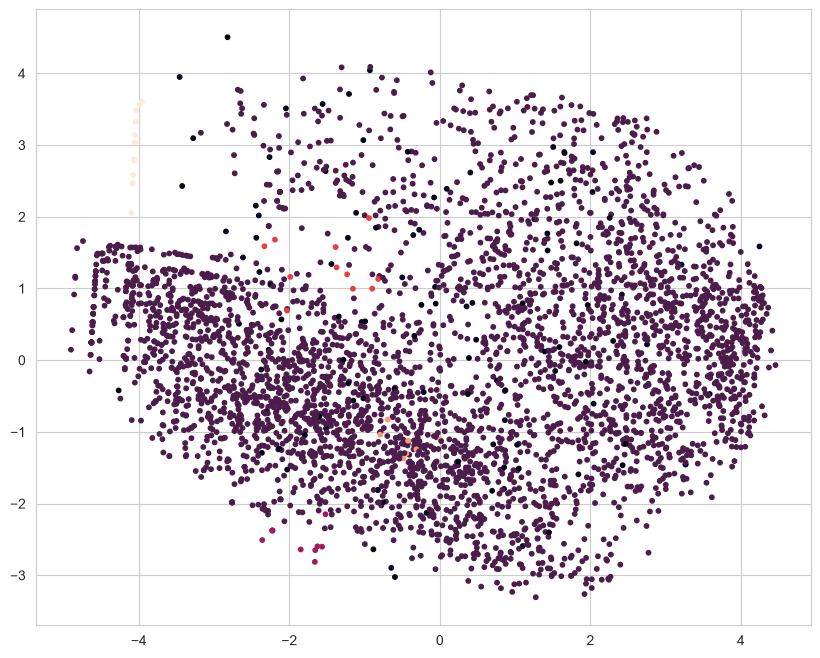

In [105]:
plt.figure(figsize=(10,8))

plt.scatter(X_pca[:,0], X_pca[:,1],  c = dbscan_new_preds, s = 10)

In [106]:
Results=[]

In [107]:
def model_evaluation(model, data, pred):

    s_score = silhouette_score(data, pred)
    db_score = davies_bouldin_score(data, pred)
    ch_score = calinski_harabasz_score(data, pred)

    return {
        "Model" : model,
        "Silhouette Score" : s_score,
        "DB Score" : db_score,
        "CH Score" : ch_score
    }

In [108]:
Results.append(model_evaluation("KMEANS", X_scaled, kmeans_Cluster))
Results.append(model_evaluation("Hierarchical", X_scaled, hierarchical_Cluster))
Results.append(model_evaluation("Gaussian Mixture", X_scaled, gmm_Cluster))

In [109]:
Results

[{'Model': 'KMEANS',
  'Silhouette Score': 0.3020690370662996,
  'DB Score': 1.1631665721440063,
  'CH Score': 2207.9253950014067},
 {'Model': 'Hierarchical',
  'Silhouette Score': 0.3020690370662996,
  'DB Score': 1.1631665721440063,
  'CH Score': 2207.9253950014067},
 {'Model': 'Gaussian Mixture',
  'Silhouette Score': 0.18658877903145205,
  'DB Score': 1.5861338967555652,
  'CH Score': 1083.9440792381986}]

By looking at the results, we find that KMeans gives the best possible results and better cluster profiling than other Algorithms.

In [110]:
product_df = product_df.drop(columns=["HierarchicalClusters", "GMMClusters", "GMMConfidence"])

In [111]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity,KMeansClusters
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28,139,5.920863,2
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45,268,1.085821,2
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39,367,0.523161,2
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24,373,3.284182,2
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23,280,8.510714,3


In [112]:
cluster_profile = product_df.groupby("KMeansClusters").agg(
    Products=("StockCode", "count"),
    AvgRevenue=("TotalRevenue", "mean"),
    AvgCustomers=("TotalCustomers", "mean"),
    AvgSalesQuantity=("TotalSalesQuantity", "mean"),
    AvgReturnQuantity=("TotalReturnQuantity", "mean"),
    AvgOrders=("TotalOrders", "mean"),
    AvgReturnValue=("TotalReturnValue", "mean"),
    AvgNetRevenue=("TotalNetRevenue", "mean"),
    AvgPrice=("AveragePrice", "mean"),
    AvgReturnRate=("ReturnRate", "mean"),
    AvgQuantityPerOrder=("QuantityPerOrder", "mean"),
    AvgRevenuePerOrder=("RevenuePerOrder", "mean"),
    AvgSalesDays=("SalesDays", "mean"),
    AvgSalesVelocity=("SalesVelocity", "mean")
).round(2)


In [113]:
cluster_profile

,Products,AvgRevenue,AvgCustomers,AvgSalesQuantity,AvgReturnQuantity,AvgOrders,AvgReturnValue,AvgNetRevenue,AvgPrice,AvgReturnRate,AvgQuantityPerOrder,AvgRevenuePerOrder,AvgSalesDays,AvgSalesVelocity
KMeansClusters,,,,,,,,,,,,,,
0,650,1967.59,58.98,370.77,26.01,83.06,131.80,1835.79,6.97,0.08,6.19,18.79,296.48,1.47
1,1134,129.90,6.12,28.51,0.27,7.00,7.76,122.14,5.87,0.03,5.19,30.48,179.03,1.08
2,1144,923.73,48.96,832.53,0.36,61.78,0.54,923.19,1.91,0.00,17.38,22.52,280.41,4.17
3,988,6482.00,170.02,3988.00,258.51,267.29,519.84,5962.16,2.24,0.02,99.40,19.00,318.62,177.50


In [114]:
cluster_summary = product_df.groupby("KMeansClusters").agg(
    Products=("StockCode", "count"),
    
    TotalRevenue=("TotalRevenue", "sum"),
    TotalSalesQuantity=("TotalSalesQuantity", "sum"),
    TotalReturnQuantity=("TotalReturnQuantity", "sum"),
    TotalOrders=("TotalOrders", "sum"),
    TotalReturnValue=("TotalReturnValue", "sum"),
    TotalNetRevenue=("TotalNetRevenue", "sum"),
    
    AvgRevenue=("TotalRevenue", "mean"),
    AvgCustomers=("TotalCustomers", "mean"),
    AvgOrders=("TotalOrders", "mean"),
    AvgReturnRate=("ReturnRate", "mean"),
    AvgPrice=("AveragePrice", "mean"),
    AvgSalesVelocity=("SalesVelocity", "mean")
).round(2).reset_index()

In [115]:
cluster_summary

,KMeansClusters,Products,TotalRevenue,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalReturnValue,TotalNetRevenue,AvgRevenue,AvgCustomers,AvgOrders,AvgReturnRate,AvgPrice,AvgSalesVelocity
0,0,650,1278932.22,241001,16907,53989,85668.71,1193263.51,1967.59,58.98,83.06,0.08,6.97,1.47
1,1,1134,147308.41,32326,303,7939,8802.44,138505.97,129.90,6.12,7.00,0.03,5.87,1.08
2,2,1144,1056748.53,952411,413,70676,613.67,1056134.86,923.73,48.96,61.78,0.00,1.91,4.17
3,3,988,6404219.73,3940148,255412,264079,513604.65,5890615.08,6482.00,170.02,267.29,0.02,2.24,177.50


In [116]:
cluster_names = {
    0: "High Value / High Return Products",
    1: "Low Value Slow Mon=ving Products",
    2: "Mass-Market / Fast-Moving/ Slow Return",
    3: "High Value / High Velocity Products"
}

cluster_summary["ClusterName"] = (
    cluster_summary["KMeansClusters"]
    .map(cluster_names)
)

In [117]:
cluster_summary

,KMeansClusters,Products,TotalRevenue,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalReturnValue,TotalNetRevenue,AvgRevenue,AvgCustomers,AvgOrders,AvgReturnRate,AvgPrice,AvgSalesVelocity,ClusterName
0,0,650,1278932.22,241001,16907,53989,85668.71,1193263.51,1967.59,58.98,83.06,0.08,6.97,1.47,High Value / High Return Products
1,1,1134,147308.41,32326,303,7939,8802.44,138505.97,129.90,6.12,7.00,0.03,5.87,1.08,Low Value Slow Mon=ving Products
2,2,1144,1056748.53,952411,413,70676,613.67,1056134.86,923.73,48.96,61.78,0.00,1.91,4.17,Mass-Market / Fast-Moving/ Slow Return
3,3,988,6404219.73,3940148,255412,264079,513604.65,5890615.08,6482.00,170.02,267.29,0.02,2.24,177.50,High Value / High Velocity Products


🔴 Cluster 3 — High-Value / High-Velocity Products

This is clearly your most important cluster.

988 products
₹6.40M revenue
~3.94M units sold
264K orders
₹6,482 average revenue/product
267 average orders/product
177.5 sales velocity
Only ~2% return rate
Business insight

These are your star products.

They generate the majority of revenue while maintaining a relatively low return rate. The extremely high sales velocity suggests strong and consistent demand.

Business recommendations
Maintain high inventory availability.
Prioritize these products in forecasting.
Avoid stockouts.
Give them prominent placement.
Consider bundling/cross-selling.
Monitor inventory turnover closely.
Investigate whether some can support premium pricing.

This cluster should receive the highest operational priority.

🟠 Cluster 0 — High-Value but High-Return Products

This is an interesting cluster.

650 products
₹1.28M revenue
241K units sold
53,989 orders
₹1,968 average revenue/product
83 average orders/product
8% return rate
Sales velocity: 1.47

The 8% return rate is the highest among all clusters.

Business insight

These products generate substantial revenue, but their return behavior is concerning.

This could indicate:

Product quality issues
Customer dissatisfaction
Incorrect product descriptions
Product expectations not matching reality
Packaging/shipping problems
Business recommendations

Don't immediately discontinue these products.

Instead:

Investigate why customers are returning them.

Compare these products by:

Return reason
Country
Customer type
Product category
Price
Order size

This could potentially become a separate return-risk analysis.

🟡 Cluster 2 — Fast-Moving / Low-Return Products

This cluster is particularly interesting.

1,144 products
₹1.06M revenue
952K units sold
70,676 orders
₹924 average revenue/product
61.8 average orders/product
Almost 0% return rate
Sales velocity = 4.17

These products sell large quantities but generate less revenue per product than Cluster 3.

Business insight

These are your volume drivers.

Customers buy them frequently and they have very low return rates.

Business recommendations
Maintain sufficient inventory.
Use these products for promotions.
Bundle them with Cluster 3 products.
Use them to increase basket size.
Focus on efficient procurement because margins may depend heavily on volume.

A useful business strategy would be:

Cluster 3 drives value, Cluster 2 drives volume.

🟢 Cluster 1 — Low-Value / Slow-Moving Products

This is your weakest segment.

1,134 products
Only ₹147K revenue
32K units
7 average orders/product
₹129.90 average revenue/product
Sales velocity = 1.08
3% return rate

These products represent a large portion of your product portfolio but contribute relatively little revenue.

Business insight

This is potentially an underperforming / long-tail product segment.

Having 1,134 products generating only ~₹147K suggests that maintaining inventory for all of these products may not be efficient.

Business recommendations

Consider:

Reducing inventory
Promotions/discounts
Bundling
Removing consistently poor performers
Keeping them only if they serve a strategic purpose
Investigating whether some are niche products

In [118]:
fig = px.scatter(
    product_df,
    x="TotalRevenue",
    y="ReturnRate",
    color="KMeansClusters",
    hover_data=["StockCode"]
)

fig.show()

In [119]:
import joblib

In [120]:
joblib.dump(kmeans, "Kmeans.pkl")

['Kmeans.pkl']

In [121]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [124]:
product_df.to_csv("Product_df.csv", index = False)

In [125]:
product_df.head()

,StockCode,Description,TotalRevenue,TotalCustomers,TotalSalesQuantity,TotalReturnQuantity,TotalOrders,TotalMonths,TotalReturnValue,TotalNetRevenue,AveragePrice,ReturnRate,QuantityPerOrder,RevenuePerOrder,SalesDays,SalesVelocity,KMeansClusters
0,10002,INFLATABLE POLITICAL GLOBE,699.55,40,823,0,49,5,0.0,699.55,0.850000,0.000000,17.0,14.28,139,5.920863,2
1,10080,GROOVY CACTUS INFLATABLE,114.41,19,291,0,21,7,0.0,114.41,0.411905,0.000000,14.0,5.45,268,1.085821,2
2,10120,DOGGY RUBBER,40.32,25,192,0,29,9,0.0,40.32,0.210000,0.000000,7.0,1.39,367,0.523161,2
3,10125,MINI FUNKY DESIGN TAPES,929.45,49,1225,0,61,11,0.0,929.45,0.781746,0.000000,20.0,15.24,373,3.284182,2
4,10133,COLOURING PENCILS BROWN TUBE,1138.99,101,2373,10,123,10,4.2,1134.79,0.528374,0.004196,19.0,9.23,280,8.510714,3
